# MMFF94 Optimization: RDKit (CPU) vs nvMolKit (GPU)

**Tutorial 4 of the nvMolKit acceleration series.**

After generating conformers (Tutorial 3), the next step is energy-minimizing them with a force field.
[MMFF94](https://www.rdkit.org/docs/source/rdkit.Chem.rdForceFieldHelpers.html) is the standard choice.
Minimizing *many conformers across many molecules* is a large independent batch — nvMolKit runs it on the GPU
with BFGS minimization.

This notebook compares:

- **RDKit (CPU)** — `AllChem.MMFFOptimizeMoleculeConfs(mol, ...)` per molecule (single- and multi-threaded).
- **nvMolKit (GPU)** — `nvmolkit.mmffOptimization.MMFFOptimizeMoleculesConfs(mols, ...)`, batched.

Both backends start from **identical conformers** and use the **same MMFF94 settings**, so we can directly
compare the optimized per-conformer energies (a much stronger check than the stochastic ETKDG case). We keep the
molecule count small here — even a handful of molecules shows a several-fold speedup.

> **Three gotchas, handled below:**
> 1. **Import order** — `nvmolkit.mmffOptimization` must be imported *after* `nvmolkit.types`; otherwise a C++
>    converter for `BatchHardwareOptions` isn't registered yet and the import raises `TypeError`.
> 2. **MMFF parameters** — molecules lacking MMFF atom types make nvMolKit raise `ValueError`. RDKit silently
>    skips them, so we pre-filter with `MMFFHasAllMoleculeParams`.
> 3. **Empty conformers** — a molecule that fails to embed (0 conformers) makes RDKit's MMFF call raise
>    `ValueError: Bad Conformer Id`, so we keep only molecules that embedded the full conformer set.
>
> Run from this `examples/tutorials/` directory so `./nvmolkit` in the repo root doesn't shadow the install.


## 1. Setup and GPU check

In [1]:
import copy
import time

import numpy as np
import pandas as pd
import torch
from rdkit import RDLogger
from rdkit.Chem import MolFromSmiles, AddHs, AllChem
from rdkit.Chem.rdDistGeom import ETKDGv3, EmbedMultipleConfs

import nvmolkit
from nvmolkit.types import HardwareOptions                       # import BEFORE mmffOptimization
from nvmolkit.mmffOptimization import MMFFOptimizeMoleculesConfs

RDLogger.DisableLog("rdApp.*")
assert torch.cuda.is_available(), "CUDA is not available - check your torch/driver install."
print(f"nvmolkit : {nvmolkit.__version__}")
print(f"torch    : {torch.__version__}")
print(f"GPU      : {torch.cuda.get_device_name(0)}")

nvmolkit : 0.5.0
torch    : 2.12.0+cu126
GPU      : NVIDIA A100 80GB PCIe


## 2. Parameters

In [2]:
CONFS_PER_MOL = 10
N_CPU_THREADS = 16
RANDOM_SEED = 42
MAX_ITERS = 200
NONBONDED_THRESHOLD = 100.0
SIZES = [10, 25, 50]                 # number of molecules (small set; speedup shows quickly)
MIN_HEAVY, MAX_HEAVY = 15, 30
SMI_FILE = "../../benchmarks/data/chembl_10k.smi"
print(f"confs/mol={CONFS_PER_MOL}, maxIters={MAX_ITERS}, sizes={SIZES}")

confs/mol=10, maxIters=200, sizes=[10, 25, 50]


## 3. Load molecules and generate the starting conformers (once)

We keep normal-sized molecules that (a) have full MMFF parameters and (b) successfully embed all
`CONFS_PER_MOL` conformers. This conformer set is the **shared starting point** for both backends; conformer
generation is *not* part of the timed comparison (that was Tutorial 3).

In [3]:
smis = pd.read_csv(SMI_FILE, header=None, nrows=10000).iloc[:, 0].tolist()
params = ETKDGv3(); params.randomSeed = RANDOM_SEED

mols_all = []
for s in smis:
    m = MolFromSmiles(s)
    if m is None or not (MIN_HEAVY <= m.GetNumHeavyAtoms() <= MAX_HEAVY):
        continue
    mh = AddHs(m)
    if not AllChem.MMFFHasAllMoleculeParams(mh):   # nvMolKit raises on molecules without MMFF types
        continue
    EmbedMultipleConfs(mh, numConfs=CONFS_PER_MOL, params=params)
    if mh.GetNumConformers() == CONFS_PER_MOL:      # skip embedding failures (avoids 'Bad Conformer Id')
        mols_all.append(mh)
    if len(mols_all) >= max(SIZES):
        break
SIZES = [n for n in SIZES if n <= len(mols_all)]
print(f"Prepared {len(mols_all)} molecules x {CONFS_PER_MOL} conformers; sweep sizes = {SIZES}")

Prepared 50 molecules x 10 conformers; sweep sizes = [10, 25, 50]


## 4. Define the two backends

Each call optimizes *fresh copies* (same starting coordinates) and returns the flat array of optimized
per-conformer energies. RDKit returns `(not_converged, energy)` tuples per conformer; nvMolKit returns a list of
per-molecule energy lists.

In [4]:
def fresh_copies(mols):
    return [copy.deepcopy(m) for m in mols]


def rdkit_mmff(mols, num_threads=1):
    energies = []
    for m in mols:
        res = AllChem.MMFFOptimizeMoleculeConfs(
            m, numThreads=num_threads, maxIters=MAX_ITERS,
            nonBondedThresh=NONBONDED_THRESHOLD, ignoreInterfragInteractions=True,
        )
        energies.extend(e for _, e in res)
    return np.array(energies)


def nvmolkit_mmff(mols):
    ll = MMFFOptimizeMoleculesConfs(
        mols, maxIters=MAX_ITERS, nonBondedThreshold=NONBONDED_THRESHOLD,
        ignoreInterfragInteractions=True,
        hardwareOptions=HardwareOptions(preprocessingThreads=N_CPU_THREADS),
    )
    torch.cuda.synchronize()
    return np.array([e for sub in ll for e in sub])

## 5. Correctness check (optimized energies)

Same start, same force field, same iteration cap -> the optimized energies should agree closely. We compare the
per-conformer energies from both backends.

In [5]:
sample = mols_all[:max(SIZES)]
rd_e = rdkit_mmff(fresh_copies(sample), num_threads=N_CPU_THREADS)
nv_e = nvmolkit_mmff(fresh_copies(sample))

diff = np.abs(rd_e - nv_e)
print(f"conformers compared : {len(rd_e)}")
print(f"mean |Delta E|      : {diff.mean():.4f} kcal/mol")
print(f"median |Delta E|    : {np.median(diff):.4f} kcal/mol")
print(f"max  |Delta E|      : {diff.max():.3f} kcal/mol")
print(f"correlation         : {np.corrcoef(rd_e, nv_e)[0, 1]:.6f}")
print("\n(A few conformers settle in slightly different nearby minima - expected for independent minimizers.)")

conformers compared : 500
mean |Delta E|      : 0.0239 kcal/mol
median |Delta E|    : 0.0000 kcal/mol
max  |Delta E|      : 5.067 kcal/mol
correlation         : 0.999995

(A few conformers settle in slightly different nearby minima - expected for independent minimizers.)


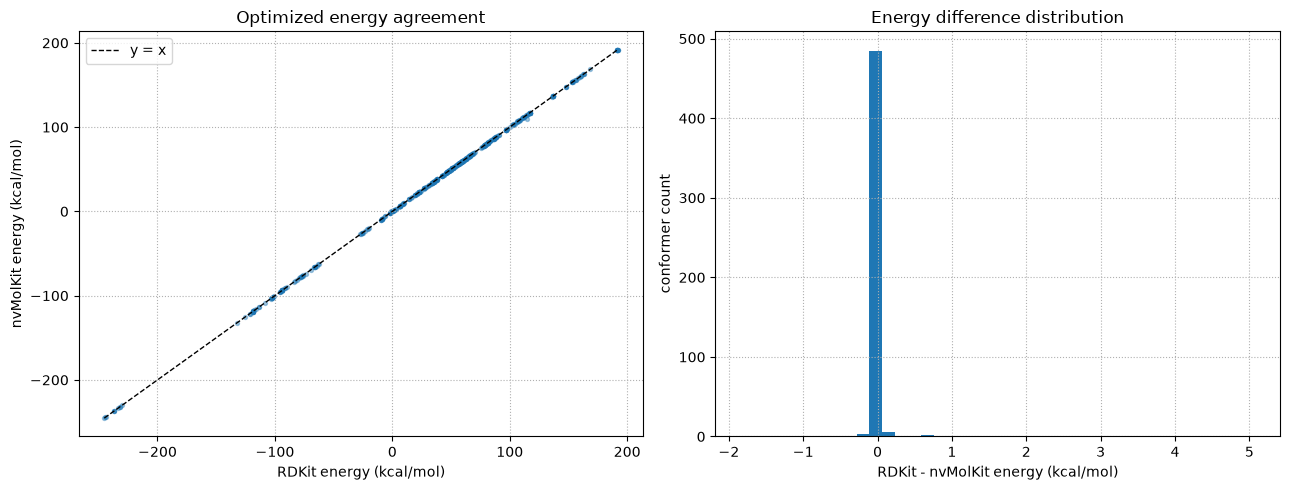

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
lo, hi = min(rd_e.min(), nv_e.min()), max(rd_e.max(), nv_e.max())
ax1.scatter(rd_e, nv_e, s=8, alpha=0.4)
ax1.plot([lo, hi], [lo, hi], "k--", lw=1, label="y = x")
ax1.set_xlabel("RDKit energy (kcal/mol)")
ax1.set_ylabel("nvMolKit energy (kcal/mol)")
ax1.set_title("Optimized energy agreement")
ax1.legend(); ax1.grid(True, ls=":")

ax2.hist(rd_e - nv_e, bins=40)
ax2.set_xlabel("RDKit - nvMolKit energy (kcal/mol)")
ax2.set_ylabel("conformer count")
ax2.set_title("Energy difference distribution")
ax2.grid(True, ls=":")
plt.tight_layout(); plt.show()

## 6. Warm up the GPU

In [7]:
_ = nvmolkit_mmff(fresh_copies(mols_all[:5]))
print("GPU warmed up.")

GPU warmed up.


## 7. Scaling benchmark

We time only the MMFF optimization (conformers are precomputed). RDKit single-thread is the naive default;
RDKit multi-thread is the fair CPU baseline.

In [8]:
def timed(fn, mols):
    t = time.perf_counter()
    fn(mols)
    torch.cuda.synchronize()
    return time.perf_counter() - t


rows = []
for n in SIZES:
    base = mols_all[:n]
    t_rd1 = timed(lambda m: rdkit_mmff(m, num_threads=1), fresh_copies(base))
    t_rdN = timed(lambda m: rdkit_mmff(m, num_threads=N_CPU_THREADS), fresh_copies(base))
    t_gpu = timed(nvmolkit_mmff, fresh_copies(base))
    total_confs = n * CONFS_PER_MOL
    rows.append({
        "n_mols": n,
        "total_confs": total_confs,
        "rdkit_1thread_s": t_rd1,
        f"rdkit_{N_CPU_THREADS}thread_s": t_rdN,
        "nvmolkit_gpu_s": t_gpu,
        "gpu_confs_per_s": total_confs / t_gpu,
        "speedup_vs_1thread": t_rd1 / t_gpu,
        f"speedup_vs_{N_CPU_THREADS}thread": t_rdN / t_gpu,
    })
    print(f"n={n:4d} | confs={total_confs:5d} | RDKit-1t {t_rd1:7.2f}s | "
          f"RDKit-{N_CPU_THREADS}t {t_rdN:6.2f}s | nvMolKit {t_gpu:6.3f}s | "
          f"speedup {t_rd1/t_gpu:6.1f}x / {t_rdN/t_gpu:5.1f}x")

df = pd.DataFrame(rows)
df

n=  10 | confs=  100 | RDKit-1t    2.34s | RDKit-16t   0.43s | nvMolKit  0.067s | speedup   34.8x /   6.4x


n=  25 | confs=  250 | RDKit-1t    6.32s | RDKit-16t   1.17s | nvMolKit  0.113s | speedup   56.0x /  10.4x


n=  50 | confs=  500 | RDKit-1t   13.12s | RDKit-16t   2.44s | nvMolKit  0.190s | speedup   69.1x /  12.9x


,n_mols,total_confs,rdkit_1thread_s,rdkit_16thread_s,nvmolkit_gpu_s,gpu_confs_per_s,speedup_vs_1thread,speedup_vs_16thread
0,10,100,2.344356,0.430544,0.067391,1483.869610,34.787180,6.388712
1,25,250,6.321671,1.169608,0.112938,2213.612156,55.974911,10.356236
2,50,500,13.117429,2.440736,0.189774,2634.715896,69.121399,12.861291


## 8. Plot: runtime and speedup vs number of molecules

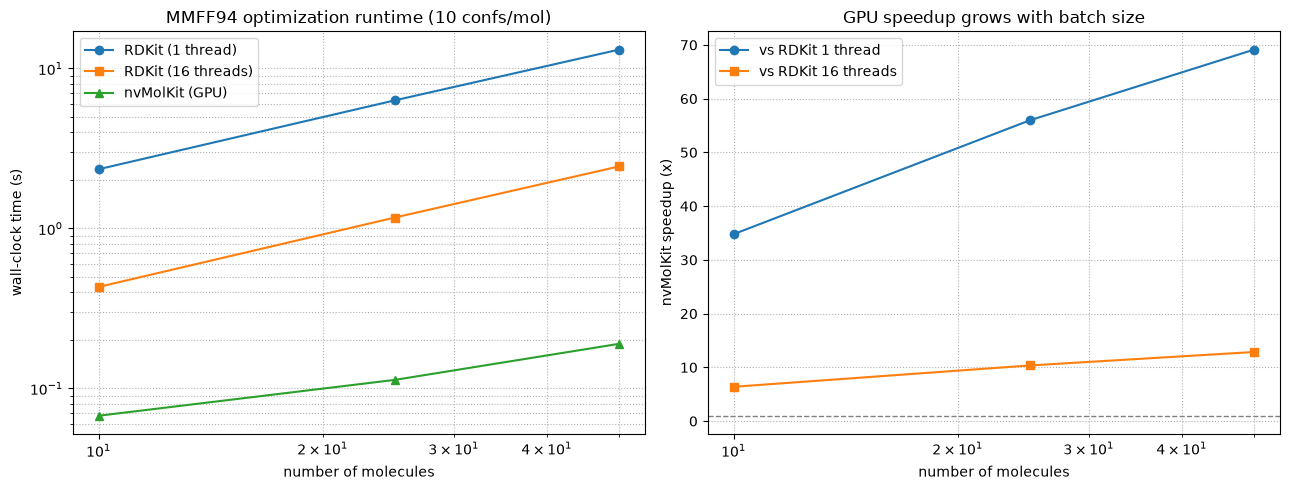

In [9]:
col_rdN = f"rdkit_{N_CPU_THREADS}thread_s"
col_spN = f"speedup_vs_{N_CPU_THREADS}thread"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(df["n_mols"], df["rdkit_1thread_s"], "o-", label="RDKit (1 thread)")
ax1.plot(df["n_mols"], df[col_rdN], "s-", label=f"RDKit ({N_CPU_THREADS} threads)")
ax1.plot(df["n_mols"], df["nvmolkit_gpu_s"], "^-", label="nvMolKit (GPU)")
ax1.set_xlabel("number of molecules")
ax1.set_ylabel("wall-clock time (s)")
ax1.set_title(f"MMFF94 optimization runtime ({CONFS_PER_MOL} confs/mol)")
ax1.set_xscale("log"); ax1.set_yscale("log")
ax1.legend(); ax1.grid(True, which="both", ls=":")

ax2.plot(df["n_mols"], df["speedup_vs_1thread"], "o-", label="vs RDKit 1 thread")
ax2.plot(df["n_mols"], df[col_spN], "s-", label=f"vs RDKit {N_CPU_THREADS} threads")
ax2.axhline(1.0, color="gray", ls="--", lw=1)
ax2.set_xlabel("number of molecules")
ax2.set_ylabel("nvMolKit speedup (x)")
ax2.set_title("GPU speedup grows with batch size")
ax2.set_xscale("log")
ax2.legend(); ax2.grid(True, which="both", ls=":")
plt.tight_layout(); plt.show()

## 9. Takeaways

- **Same minima.** Optimized MMFF energies match RDKit to a fraction of a kcal/mol on average (a handful of
  conformers land in slightly different nearby minima, as expected for independent BFGS runs).
- **Several-fold speedup from just a handful of molecules**, growing as the batch grows — the regime for
  conformer-library refinement.
- **Three practical notes.** Import `nvmolkit.types` before `nvmolkit.mmffOptimization`; pre-filter with
  `MMFFHasAllMoleculeParams`; and drop molecules that failed to embed (0 conformers).
- **Stay on-device / add constraints.** Use `output=CoordinateOutput.DEVICE` to keep optimized coordinates on
  the GPU; use `MMFFBatchedForcefield` for custom options and constraints (Tutorial 6).

**Next:** Tutorial 5 repeats this for the UFF force field.